## 3장 1강: 다중 회귀와 규제 모델

## 1. 정규화 규제 (Regularization)

기본 데이터 오차 Loss에 가중치 패널티를 더해,

가중치가 과도하게 커지는 것을 막고 과적합을 줄인다.

적절한 규제로 과소적합/과대적합을 막는다.

- 강한 영향력의 특성 -> y값 변화 크고 w의 값이 큼
- 약한 영향력의 특성 -> y값 변화 크지 않고 w값 작음
> 아래 예시는 데이터 오차로 MSE를 사용한 경우이다.  
> MAE 등 다른 데이터 오차 함수와도 조합할 수 있다.

### L2 규제 (Ridge)

가중치의 **제곱**에 패널티를 준다.

$$
Loss_{\text{total}}
=
MSE
+
\lambda \sum_{j=1}^{p} w_j^2
$$

- 기존 Loss값 (MSE) 자체에 더함
- 가중치의 영향력이 작으면 작은 패널티를 받는다. (Loss값 작게 높이기)
- 가중치의 영향력이 크면 제곱에 비례하여 매우 큰 패널티를 받는다. 패널티(Loss값 크게 올리기)
- 큰 가중치를 부드럽게 줄인다.
- 대부분의 가중치를 0에 가깝게 만들지만, 정확히 0으로 만들지는 않는다
- 가장 많이 쓰는 규제

### L1 규제 (Lasso)

가중치의 **절댓값**에 패널티를 준다.(Loss값을 올림)

$$
Loss_{\text{total}}
=
MSE
+
\lambda \sum_{j=1}^{p} |w_j|
$$

- 중요도가 낮은 feature의 가중치를 정확히 0으로 만들 수 있다.
- 가중치가 0이 된 feature는 예측에 사용되지 않는다.
- 따라서 feature 선택 효과가 있다.

### 기호

- $w_j$: $j$번째 feature의 가중치
- $p$: feature(특성)의 개수, 즉 가중치의 개수
- $\lambda \geq 0$: 규제 강도를 정하는 하이퍼파라미터
  - $\lambda$가 클수록 가중치 제한이 강해진다.
  - 너무 크면 필요한 feature까지 충분히 학습하지 못할 수 있다.

| 구분 | Min-Max / Z-score | Ridge / Lasso |
|---|---|---|
| 정확한 구분 | **Feature Scaling** (전처리) | **Regularization** (규제) |
| 대상 | 입력 feature 값 \(X\) | 모델 가중치 \(w\) |
| 목적 | 단위·범위를 맞춤 | 과적합 방지 |
| 적용 시점 | 학습 전 | Loss 함수 안에서 학습 중 |
| 가중치 변화 | 직접 조정하지 않음 | 큰 가중치에 패널티 |
| 예시 | 면적 \(10\sim1000\), 학군 \(1\sim5\)의 스케일 통일 | 불필요하게 큰 \(w\)를 줄임 |

### Feature Scaling

$$
x' = \frac{x-x_{\min}}{x_{\max}-x_{\min}}
$$

또는

$$
z = \frac{x-\mu}{\sigma}
$$

### Regularization

$$
Loss_{\text{total}} = Loss_{\text{data}} + \lambda \sum_i w_i^2
$$

## 2. 특성 공학
- 특성들을 조합해서 새로운 특성을 추가해 주는 전처리 기법
- 너무 특성의 갯수를 늘리면 -> 과대적합 
- 적절하게 늘린다.

### 4. Student Performance 데이터셋 분석
#### 3.1 데이터 준비 및 가공하기

머신러닝 데이터 가공과 시각화에 필요한 필수 도구들을 불러옵니다.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler, PolynomialFeatures #PolynomialFeatures - 특성공학 구현

sklearn.set_config(display='text')

난수를 고정하여 매번 돌릴 때마다 동일한 분석 결과가 나오도록 처리

In [78]:
np.random.seed(42)

학생 성적(student-por.csv) 불러오기

In [79]:
df = pd.read_csv("student-por.csv")
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


분석을 위한 변수 3가지를 독립변수(특성, Feature)로 지정
- studytime: 주당 자습 시간 (1~4 범위)
- freetime: 방과 후 자유 시간 (1~5 범위)
- absences: 학기 중 최종 결석 횟수 (0~93 범위)

In [80]:
X = df[['studytime', 'freetime', 'absences']]
y = df['G3']

X.head()

,studytime,freetime,absences
0,2,3,4
1,2,3,2
2,2,3,6
3,3,2,0
4,2,3,0


특성 공학(Polynomial Features)을 적용하여 3개의 기본 축을 제곱항과 상호작용항이 포함된 9개 컬럼으로 확장합니다.

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False) # 가중치 특성들만

X_poly = poly.fit_transform(X) # 준비 fit, 변경 transform

X_poly.shape

(649, 9)

In [82]:
feature_names = poly.get_feature_names_out(X.columns)
feature_names

array(['studytime', 'freetime', 'absences', 'studytime^2',
       'studytime freetime', 'studytime absences', 'freetime^2',
       'freetime absences', 'absences^2'], dtype=object)

자습 시간(1~4단계)과 결석 일수(0~93일)의 척도가 크게 다르므로, 이를 동일한 스케일(표준점수)로 맞춰줍니다.

In [83]:
ss = StandardScaler()
X_scaled = ss.fit_transform(X_poly)

X_scaled[:10]

array([[ 0.08365295, -0.17164654,  0.07343336, -0.10972085, -0.02499704,
         0.15793558, -0.33462543,  0.02851214, -0.21578478],
       [ 0.08365295, -0.17164654, -0.35786305, -0.10972085, -0.02499704,
        -0.29661072, -0.33462543, -0.34912826, -0.35282562],
       [ 0.08365295, -0.17164654,  0.50472977, -0.10972085, -0.02499704,
         0.61248188, -0.33462543,  0.40615254,  0.01261663],
       [ 1.29011438, -1.12377133, -0.78915946,  1.21386342, -0.02499704,
        -0.75115702, -1.08921856, -0.72676866, -0.3985059 ],
       [ 0.08365295, -0.17164654, -0.78915946, -0.10972085, -0.02499704,
        -0.75115702, -0.33462543, -0.72676866, -0.3985059 ],
       [ 0.08365295,  0.78047826,  0.50472977, -0.10972085,  0.59896758,
         0.61248188,  0.72180496,  0.78379295,  0.01261663],
       [ 0.08365295,  0.78047826, -0.78915946, -0.10972085,  0.59896758,
        -0.75115702,  0.72180496, -0.72676866, -0.3985059 ],
       [ 0.08365295, -2.07589613, -0.35786305, -0.10972085, -1

#### 3.3 모델 학습 및 시각화

모델 학습 및 규제를 위한 도구를 불러옵니다.

In [84]:
from sklearn.linear_model import Ridge, Lasso


규제 강도(alpha)를 로그 스케일로 0.001부터 1000까지 넓은 범위에 걸쳐 200단계로 나누어 설정합니다.

In [85]:
alphas = np.logspace(-3, 3, 200) # 로그값 범위 설정
alphas[:10]

array([0.001     , 0.00107189, 0.00114895, 0.00123155, 0.00132009,
       0.00141499, 0.00151672, 0.00162576, 0.00174263, 0.00186791])

모델 학습하기

In [88]:
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge 모델 가중치 저장
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)

    # Lasso 모델 가중치 저장
    lasso = Lasso(alpha=a, max_iter=20000, tol=1e-4)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)


# 가중치 확인
print(ridge_coefs[:5])
print(lasso_coefs[:5])


[array([ 2.24379625,  0.58889643,  0.51051007, -1.04787847, -0.34823071,
       -0.66211807, -0.72031432, -0.10287111, -0.01701943]), array([ 2.24378458,  0.58889119,  0.51050615, -1.04787087, -0.34822647,
       -0.66211603, -0.72031189, -0.1028699 , -0.01701855]), array([ 2.24377207,  0.58888557,  0.51050195, -1.04786272, -0.34822192,
       -0.66211384, -0.72030929, -0.10286861, -0.01701761]), array([ 2.24375866,  0.58887954,  0.51049745, -1.04785398, -0.34821705,
       -0.66211149, -0.72030651, -0.10286723, -0.01701659]), array([ 2.24374429,  0.58887308,  0.51049262, -1.04784462, -0.34821183,
       -0.66210898, -0.72030352, -0.10286574, -0.01701551])]
[array([ 2.16648238e+00,  5.15261289e-01,  4.48421227e-01, -1.00659433e+00,
       -3.10897183e-01, -6.40036990e-01, -6.75950460e-01, -7.39144058e-02,
       -1.73073998e-03]), array([ 2.16091513e+00,  5.09955822e-01,  4.43952690e-01, -1.00362080e+00,
       -3.08209338e-01, -6.38447740e-01, -6.72752344e-01, -7.18303317e-02,
       

시각화 하기

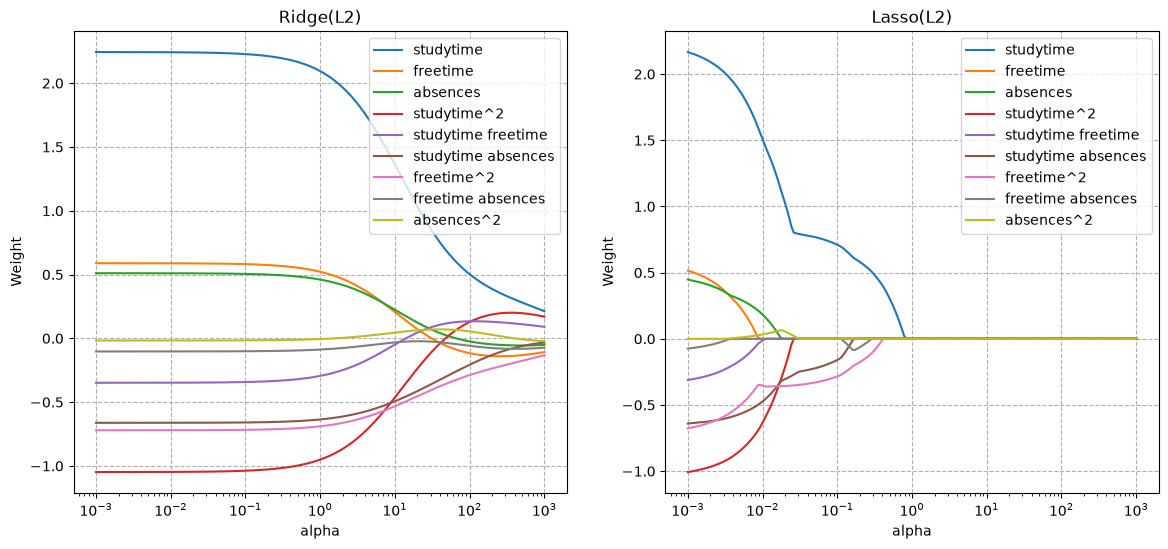

In [90]:
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i in range(X_scaled.shape[1]): #.shape=> tuple
    axes[0].plot(alphas, ridge_coefs[:, i], label=feature_names[i])


axes[0].set_xscale('log') # alpha -> log값 형태로 바꿔줌
axes[0].set_title("Ridge(L2)")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("Weight")
axes[0].grid(True, linestyle='--')
axes[0].legend()

for i in range(X_scaled.shape[1]): #.shape=> tuple
    axes[1].plot(alphas, lasso_coefs[:, i], label=feature_names[i])


axes[1].set_xscale('log') # alpha -> log값 형태로 바꿔줌
axes[1].set_title("Lasso(L2)")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("Weight")
axes[1].grid(True, linestyle='--')
axes[1].legend()


plt.show()